In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.utils.team_info import *
from src.utils.helper_functions import *
from src.pipeline.props_pipeline.ppm_pipeline import *
from src.pipeline.props_pipeline.min_pipeline import *
from src.features.feature_engineer.ppm_features import ppm_features

warnings.filterwarnings("ignore")

In [2]:
pd.set_option('display.max_columns', None)

s23 = pd.read_csv('data/raw/season_stats/S23.csv').sort_values(by='GAME_DATE')
s24 = pd.read_csv('data/raw/season_stats/S24.csv').sort_values(by='GAME_DATE')
s25 = pd.read_csv('data/raw/season_stats/S25.csv').sort_values(by='GAME_DATE')
s25['STARTING'] = s25['START_POSITION'].notna().astype(int)
s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')
s26['STARTING'] = s26['START_POSITION'].notna().astype(int)
s26.tail()

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION,pos,age,STARTING
209,2025-26,201145,Jeff Green,Jeff,1610612745,HOU,Houston Rockets,22501194,2026-04-12T00:00:00,HOU vs. MEM,W,24.183333,2,8,0.250,0,4,0.00,2,2,1.000,2,3,5,1,3,1,1,0,2,1,6,7,16.5,0,0,16.0,1,24:11,1,103.9,105.5,105.5,86.1,91.1,91.1,17.8,14.4,14.4,0.059,0.33,7.7,0.063,0.100,0.081,23.1,23.3,0.250,0.338,0.174,0.181,114.13,110.16,91.80,110.16,0.016,55,2.0,8.0,48,105,0.457,14,49,0.286,22,30,0.733,21,43,64,23,11.0,10,8,6,10,24,132,31.0,122.0,128.2,94.9,98.1,27.1,30.1,0.479,2.09,14.9,0.452,0.821,0.627,0.107,0.524,0.558,107.3,103.0,85.83,103,0.642,1610612763,MEM,Memphis Grizzlies,39,95,0.411,13,49,0.265,10,10,1.000,6,31,37,23,13.0,8,6,8,24,10,101,-31.0,94.9,98.1,122.0,128.2,-27.1,-30.1,0.590,1.77,16.9,0.179,0.548,0.373,0.126,0.479,0.508,107.3,103.0,85.83,103,0.358,NaN,PF,39.0,0
210,2025-26,1631342,Daeqwon Plowden,Daeqwon,1610612758,SAC,Sacramento Kings,22501200,2026-04-12T00:00:00,SAC @ POR,L,22.200000,2,5,0.400,1,4,0.25,3,3,1.000,0,1,1,2,3,0,2,0,4,1,8,-8,15.2,0,0,16.0,1,22:12,1,118.2,114.6,114.6,127.2,134.0,134.0,-9.0,-19.5,-19.5,0.100,0.67,18.2,0.000,0.034,0.022,27.3,26.5,0.500,0.633,0.173,0.184,103.83,102.70,85.59,102.70,0.017,48,2.0,5.0,40,83,0.482,7,21,0.333,23,31,0.742,15,32,47,24,17.0,7,8,3,18,21,110,-12.0,111.5,112.2,120.1,123.2,-8.6,-11.0,0.600,1.41,17.3,0.370,0.600,0.495,0.173,0.524,0.569,100.1,98.5,82.08,98,0.478,1610612757,POR,Portland Trail Blazers,47,101,0.465,16,46,0.348,12,15,0.800,18,28,46,28,12.0,9,3,8,21,18,122,12.0,120.1,123.2,111.5,112.2,8.6,11.0,0.596,2.33,18.8,0.400,0.630,0.505,0.121,0.545,0.567,100.1,98.5,82.08,99,0.522,F,SG,27.0,1
211,2025-26,1630286,Trevon Scott,Trevon,1610612751,BKN,Brooklyn Nets,22501192,2026-04-12T00:00:00,BKN @ TOR,L,26.050000,3,8,0.375,2,5,0.40,0,0,0.000,1,2,3,1,2,1,0,0,2,0,8,-17,14.1,0,0,16.0,1,26:03,1,104.8,109.3,109.3,137.8,135.7,135.7,-32.9,-26.5,-26.5,0.053,0.50,9.1,0.038,0.125,0.071,18.2,18.2,0.500,0.500,0.164,0.161,102.67,101.34,84.45,101.34,0.027,54,3.0,8.0,35,86,0.407,9,34,0.265,22,29,0.759,13,25,38,21,16.0,9,0,8,27,20,101,-35.0,99.3,101.0,136.3,136.0,-37.1,-35.0,0.600,1.31,15.6,0.255,0.844,0.471,0.160,0.459,0.511,100.8,100.0,83.33,100,0.277,1610612761,TOR,Toronto Raptors,51,80,0.638,12,27,0.444,22,29,0.759,3,40,43,36,10.0,9,8,0,20,27,136,35.0,136.3,136.0,99.3,101.0,37.1,35.0,0.706,3.60,25.5,0.156,0.745,0.529,0.100,0.713,0.733,100.8,100.0,83.33,100,0.723,C,NaN,NaN,1
204,2025-26,1629020,Jarred Vande

In [3]:
res = []
for df in [s23, s24, s25, s26]:
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)

    # Derived features
    df['MIN'] = df['MIN'].round(2)
    df["PTS_PER_MIN"] = df["PTS"] / df["MIN"].replace(0, np.nan)
    df['PTS_PER_POSS'] = df['PTS'] / df['POSS'].replace(0, np.nan)
    df['POSS_PER_MIN'] = df['POSS'] / df['MIN'].replace(0, np.nan)
    df['FGA_PER_MIN'] = df['FGA'] / df['MIN'].replace(0, np.nan)
    df['3PA_PER_MIN'] = df['FG3A'] / df['MIN'].replace(0, np.nan)
    df['FTA_PER_MIN'] = df['FTA'] / df['MIN'].replace(0, np.nan)
    # df['STARTING'] = df['START_POSITION'].notna().astype(int)
    # df['BAYES_PPM_PROJ'] = apply_bayesian_ppm(df)
    df = ppm_features(df)
    df['TEAM_PTS_PER_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['PTS_PER_MIN_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_PTS_PER_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['PTS_PER_MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_USG_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['USG_PCT_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_TS_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['TS_PCT_roll10'].rank(ascending=False, method='dense'))
    df['TRUE_USG_L10'] = df['POSS_roll10'] / df['TEAM_POSS_roll10']

    df['PPM_MOMENTUM'] = df['PTS_PER_MIN_5_ewm'] - df['PTS_PER_MIN_10_ewm']

    df['POSS_DIFF_L10'] = df['POSS_roll10'] - df['TEAM_POSS_roll10']
    df['TS_PCT_DELTA'] = df['TS_PCT_roll10'] - df['TEAM_TS_PCT_roll10']

    df['TS_PCT_X_USG_PCT_L10'] = df['TS_PCT_roll10'] * df['USG_PCT_roll10']
    df['PPM_MIN_L10'] = df['PTS_PER_MIN'].shift(1).rolling(10).min()
    df['PPM_MAX_L10'] = df['PTS_PER_MIN'].shift(1).rolling(10).max()
    df['USG_PCT_MIN_L10'] = df['USG_PCT'].shift(1).rolling(10).min()
    df['USG_PCT_MAX_L10'] = df['USG_PCT'].shift(1).rolling(10).max()
    df['FPM_MIN_L10'] = df['FGA_PER_MIN'].shift(1).rolling(10).min()
    df['FPM_MAX_L10'] = df['FGA_PER_MIN'].shift(1).rolling(10).max()
    
    df["GP"] = df.groupby("PLAYER_ID").cumcount()
    le = LabelEncoder()
    df['POSITION_ENC'] = le.fit_transform(df['pos'])

    df = df[df['MIN'] >= 10]
    res.append(df)

df = pd.concat(res, ignore_index=True)
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.shape)
df.tail()

(88827, 323)


,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,pos,age,STARTING,PTS_PER_MIN,PTS_PER_POSS,POSS_PER_MIN,FGA_PER_MIN,3PA_PER_MIN,FTA_PER_MIN,MIN_roll3,PTS_roll3,USG_PCT_roll3,PLUS_MINUS_roll3,POSS_roll3,PTS_PER_MIN_roll3,PTS_PER_POSS_roll3,TS_PCT_roll3,AST_TO_roll3,FGA_PER_MIN_roll3,3PA_PER_MIN_roll3,FTA_PER_MIN_roll3,AST_roll3,TOV_roll3,MIN_roll5,PTS_roll5,USG_PCT_roll5,PLUS_MINUS_roll5,POSS_roll5,PTS_PER_MIN_roll5,PTS_PER_POSS_roll5,TS_PCT_roll5,AST_TO_roll5,FGA_PER_MIN_roll5,3PA_PER_MIN_roll5,FTA_PER_MIN_roll5,AST_roll5,TOV_roll5,MIN_roll10,PTS_roll10,USG_PCT_roll10,PLUS_MINUS_roll10,POSS_roll10,PTS_PER_MIN_roll10,PTS_PER_POSS_roll10,TS_PCT_roll10,AST_TO_roll10,FGA_PER_MIN_roll10,3PA_PER_MIN_roll10,FTA_PER_MIN_roll10,AST_roll10,TOV_roll10,MIN_3_ewm,PTS_3_ewm,USG_PCT_3_ewm,PLUS_MINUS_3_ewm,POSS_3_ewm,PTS_PER_MIN_3_ewm,PTS_PER_POSS_3_ewm,POSS_PER_MIN_3_ewm,TS_PCT_3_ewm,AST_TO_3_ewm,FGA_PER_MIN_3_ewm,3PA_PER_MIN_3_ewm,FTA_PER_MIN_3_ewm,AST_3_ewm,TOV_3_ewm,MIN_5_ewm,PTS_5_ewm,USG_PCT_5_ewm,PLUS_MINUS_5_ewm,POSS_5_ewm,PTS_PER_MIN_5_ewm,PTS_PER_POSS_5_ewm,POSS_PER_MIN_5_ewm,TS_PCT_5_ewm,AST_TO_5_ewm,FGA_PER_MIN_5_ewm,3PA_PER_MIN_5_ewm,FTA_PER_MIN_5_ewm,AST_5_ewm,TOV_5_ewm,MIN_10_ewm,PTS_10_ewm,USG_PCT_10_ewm,PLUS_MINUS_10_ewm,POSS_10_ewm,PTS_PER_MIN_10_ewm,PTS_PER_POSS_10_ewm,POSS_PER_MIN_10_ewm,TS_PCT_10_ewm,AST_TO_10_ewm,FGA_PER_MIN_10_ewm,3PA_PER_MIN_10_ewm,FTA_PER_MIN_10_ewm,AST_10_ewm,TOV_10_ewm,MIN_lag1,PTS_lag1,PLUS_MINUS_lag1,PIE_lag1,STARTING_lag1,POSS_lag1,USG_PCT_lag1,PTS_PER_MIN_lag1,3PA_PER_MIN_lag1,FTA_PER_MIN_lag1,POSS_PER_MIN_lag1,MIN_lag2,PTS_lag2,PLUS_MINUS_lag2,PIE_lag2,STARTING_lag2,POSS_lag2,USG_PCT_lag2,PTS_PER_MIN_lag2,3PA_PER_MIN_lag2,FTA_PER_MIN_lag2,POSS_PER_MIN_lag2,STARTER_ROLL10_PCT,MIN_season_avg,PTS_season_avg,USG_PCT_season_avg,POSS_season_avg,PF_season_avg,OFF_RATING_season_avg,DEF_RATING_season_avg,PTS_PER_MIN_season_avg,NET_RATING_roll5,TEAM_PACE_roll10,TEAM_PTS_roll10,TEAM_POSS_roll10,TEAM_TS_PCT_roll10,MIN_share_proxy,PTS_share_proxy,DAYS_REST,IS_B2B,IS_HOME,GAME_NUMBER,MIN_std10,OPP_DEF_RATING_roll5,OPP_DEF_RATING_roll10,OPP_PACE_roll5,OPP_PACE_roll10,OPP_POSS_roll5,OPP_POSS_roll10,EXPECTED_PACE,PACE_DIFFERENTIAL,IS_TOP_STAR,ACTIVE_STARS_COUNT,TEAM_PTS_PER_MIN_RANK_L5,TEAM_PTS_PER_MIN_RANK_L10,TEAM_MIN_RANK_L10,TEAM_MIN_RANK_L5,TEAM_USG_RANK_L10,TEAM_TS_RANK_L10,TRUE_USG_L10,PPM_MOMENTUM,POSS_DIFF_L10,TS_PCT_DELTA,TS_PCT_X_USG_PCT_L10,PPM_MIN_L10,PPM_MAX_L10,USG_PCT_MIN_L10,USG_PCT_MAX_L10

In [ ]:
PPM_FEATURES = [
    # Core efficiency
    'PTS_PER_MIN_10_ewm',
    'PTS_PER_POSS_10_ewm',
    'POSS_PER_MIN_10_ewm',
    'FGA_PER_MIN_10_ewm',
    'FTA_PER_MIN_10_ewm',
    '3PA_PER_MIN_10_ewm',       
    
    # Usage
    'USG_PCT_10_ewm',
    'USG_PCT_MAX_L10',          # ceiling usage
    
    # Momentum
    'PPM_MOMENTUM',
    'PPM_MAX_L10',
    
    # Role context
    'IS_TOP_STAR',
    'ACTIVE_STARS_COUNT',
    
    # Team context
    'TEAM_MIN_RANK_L10',
    'TEAM_USG_RANK_L10',
    'TEAM_PTS_PER_MIN_RANK_L10',
    
    # Opponent
    'OPP_DEF_RATING_roll10',
    'OPP_POSS_roll10',
]

In [9]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# ── 1. Base dataframe ─────────────────────────────────────────────────────────
ppm_df = df[PPM_FEATURES + ["PTS_PER_MIN", "GAME_DATE"]].dropna().sort_values("GAME_DATE").reset_index(drop=True)
print(ppm_df.shape)

# ── 2. Walk-forward folds ─────────────────────────────────────────────────────
N_FOLDS   = 4
min_train = int(len(ppm_df) * 0.50)
fold_size = (len(ppm_df) - min_train) // N_FOLDS

fold_results = []

for fold in range(N_FOLDS):
    train_end = min_train + fold * fold_size
    val_end   = train_end + fold_size

    train_idx = ppm_df.index[:train_end]
    val_idx   = ppm_df.index[train_end:val_end]

    X_train_f = ppm_df.loc[train_idx, PPM_FEATURES]
    X_val_f   = ppm_df.loc[val_idx,   PPM_FEATURES]
    y_train_f = ppm_df.loc[train_idx, "PTS_PER_MIN"]
    y_val_f   = ppm_df.loc[val_idx,   "PTS_PER_MIN"]

    # ── 3. Quantile models ────────────────────────────────────────────────────
    quantiles       = [0.10, 0.50, 0.90]
    quantile_models = {}
    quantile_preds  = {}

    for q in quantiles:
        xgb_q = XGBRegressor(
            objective="reg:quantileerror",
            quantile_alpha=q,
            n_estimators=1378,
            max_depth=6,
            learning_rate=0.012114761889717784,
            subsample=0.658891356913107,
            colsample_bytree=0.6610449450867388,
            reg_alpha=0.35062788508631587,
            reg_lambda=0.7792871271834488,
            min_child_weight=4,
            n_jobs=-1,
            random_state=42,
            early_stopping_rounds=50,
        )
        xgb_q.fit(
            X_train_f, y_train_f,
            eval_set=[(X_val_f, y_val_f)],
            verbose=False,
        )
        quantile_models[f"q_{q:.2f}"] = xgb_q
        quantile_preds[f"q_{q:.2f}"]  = xgb_q.predict(X_val_f)

    # ── 4. Fold diagnostics ───────────────────────────────────────────────────
    actual   = y_val_f.values
    lower    = quantile_preds["q_0.10"]
    median   = quantile_preds["q_0.50"]
    upper    = quantile_preds["q_0.90"]
    coverage = np.mean((actual >= lower) & (actual <= upper))

    fold_metrics = {
        "fold":           fold + 1,
        "train_rows":     len(train_idx),
        "val_rows":       len(val_idx),
        "mae":            mean_absolute_error(actual, median),
        "r2":             r2_score(actual, median),
        "coverage_80pct": coverage,
        "best_iters":     {f"q_{q:.2f}": quantile_models[f"q_{q:.2f}"].best_iteration
                           for q in quantiles},
    }
    fold_results.append(fold_metrics)

    print(f"Fold {fold+1} | MAE: {fold_metrics['mae']:.3f} | "
          f"R²: {fold_metrics['r2']:.3f} | "
          f"80% Coverage: {coverage:.1%} | "
          f"Best iters: {fold_metrics['best_iters']}")

# ── 5. Summary ────────────────────────────────────────────────────────────────
maes      = [f["mae"]            for f in fold_results]
r2s       = [f["r2"]             for f in fold_results]
coverages = [f["coverage_80pct"] for f in fold_results]

print(f"\n{'─'*55}")
print(f"Walk-Forward Summary ({N_FOLDS} folds)")
print(f"  MAE      : {np.mean(maes):.3f} ± {np.std(maes):.3f}")
print(f"  R²       : {np.mean(r2s):.3f} ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(coverages):.1%} ± {np.std(coverages):.1%}  (target ~80%)")

(73108, 19)
Fold 1 | MAE: 0.164 | R²: 0.288 | 80% Coverage: 79.2% | Best iters: {'q_0.10': 310, 'q_0.50': 335, 'q_0.90': 450}
Fold 2 | MAE: 0.164 | R²: 0.265 | 80% Coverage: 79.4% | Best iters: {'q_0.10': 407, 'q_0.50': 381, 'q_0.90': 260}
Fold 3 | MAE: 0.163 | R²: 0.309 | 80% Coverage: 78.7% | Best iters: {'q_0.10': 376, 'q_0.50': 470, 'q_0.90': 365}
Fold 4 | MAE: 0.168 | R²: 0.266 | 80% Coverage: 78.2% | Best iters: {'q_0.10': 541, 'q_0.50': 626, 'q_0.90': 455}

───────────────────────────────────────────────────────
Walk-Forward Summary (4 folds)
  MAE      : 0.165 ± 0.002
  R²       : 0.282 ± 0.018
  Coverage : 78.9% ± 0.5%  (target ~80%)


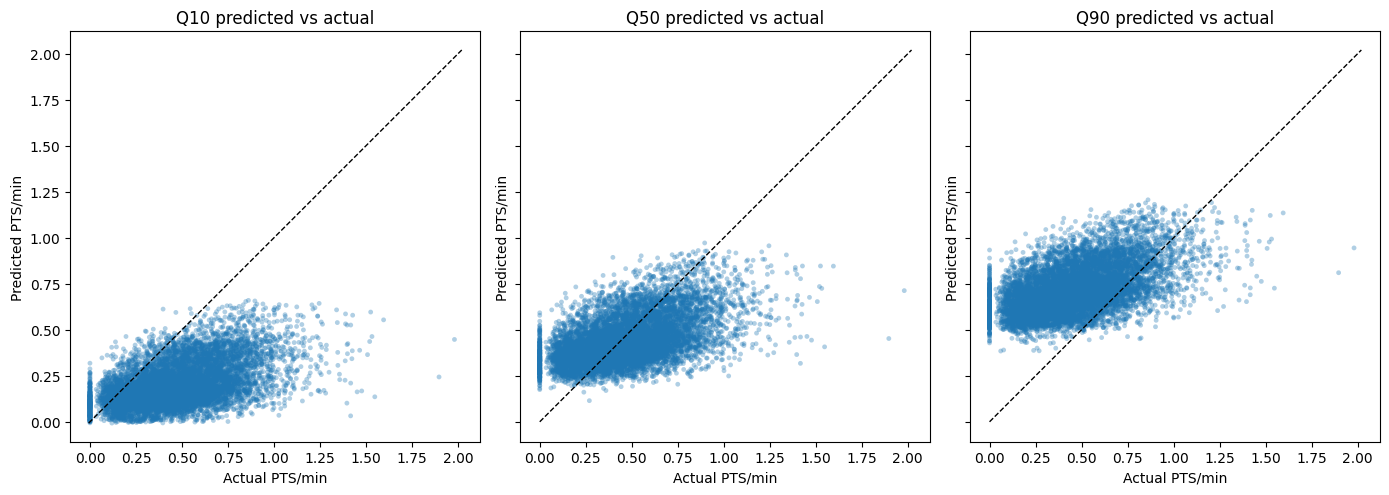

Q10 P(y ≤ pred): 0.10374261326329613
Q50 P(y ≤ pred): 0.48249069818340995
Q90 P(y ≤ pred): 0.8858612387831035
Coverage (10–90 interval): 78.21%


In [10]:
import matplotlib.pyplot as plt

y_true = y_val_f
preds = {
    "Q10": quantile_preds["q_0.10"],
    "Q50": quantile_preds["q_0.50"],
    "Q90": quantile_preds["q_0.90"],
}

fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_true, y_pred, s=12, edgecolors="none", alpha=0.35)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    lims = [lo, hi * 1.02 if hi > 0 else hi + 0.01]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name} predicted vs actual")
    ax.set_xlabel("Actual PTS/min")
    ax.set_ylabel("Predicted PTS/min")
    ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

for name, y_pred in preds.items():
    print(name, "P(y ≤ pred):", (y_true <= y_pred).mean())

pred_low = quantile_preds["q_0.10"]
pred_mid = quantile_preds["q_0.50"]
pred_high = quantile_preds["q_0.90"]

coverage = ((y_true >= pred_low) & (y_true <= pred_high)).mean()
print(f"Coverage (10–90 interval): {coverage:.2%}")  # target ~80%


── q_0.10 ──


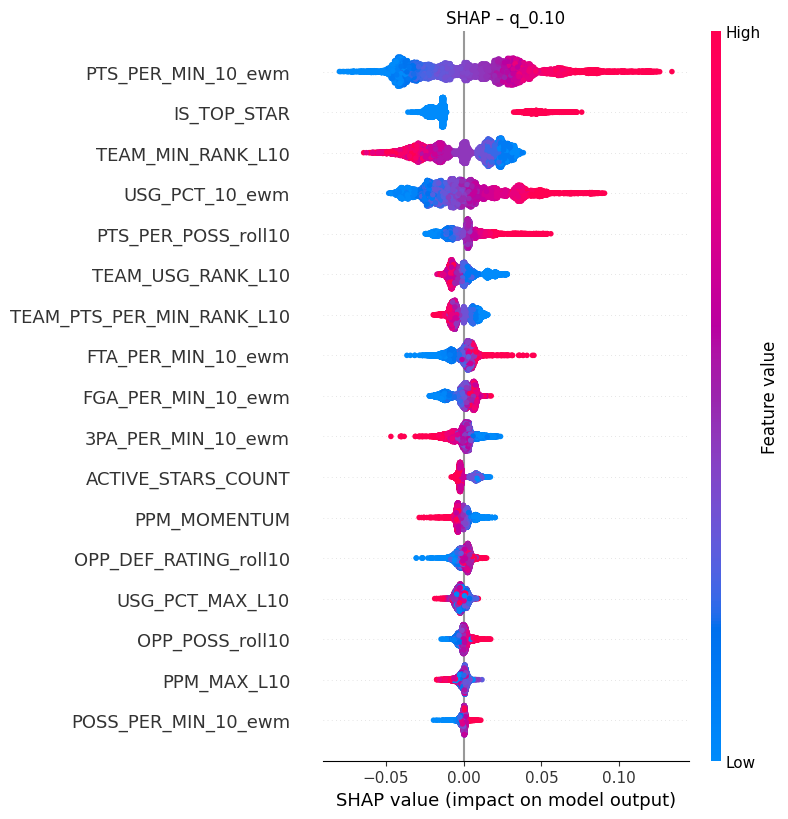


── q_0.50 ──


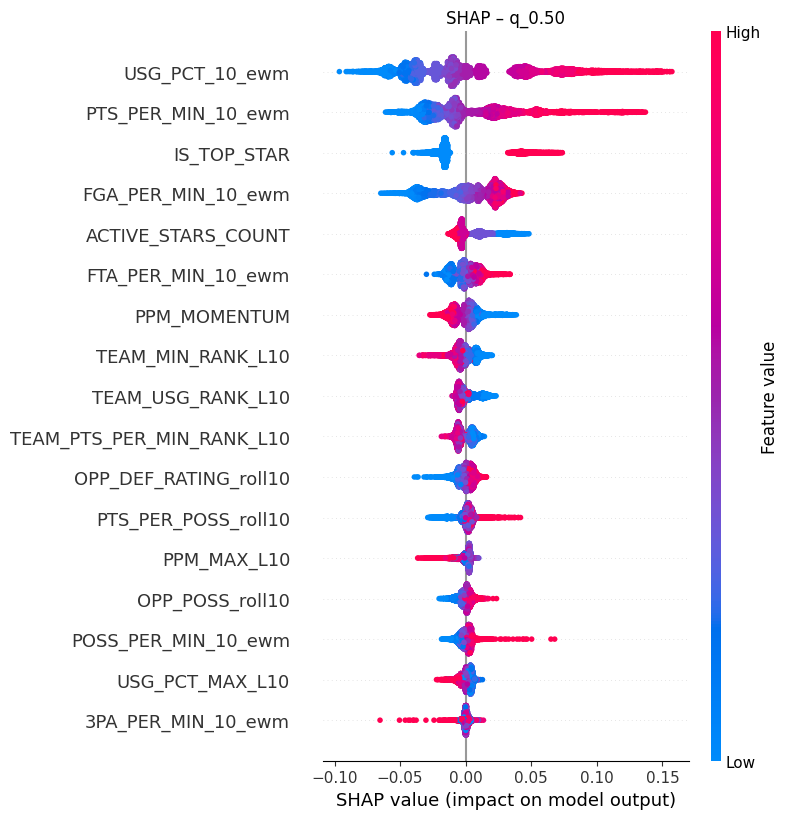


── q_0.90 ──


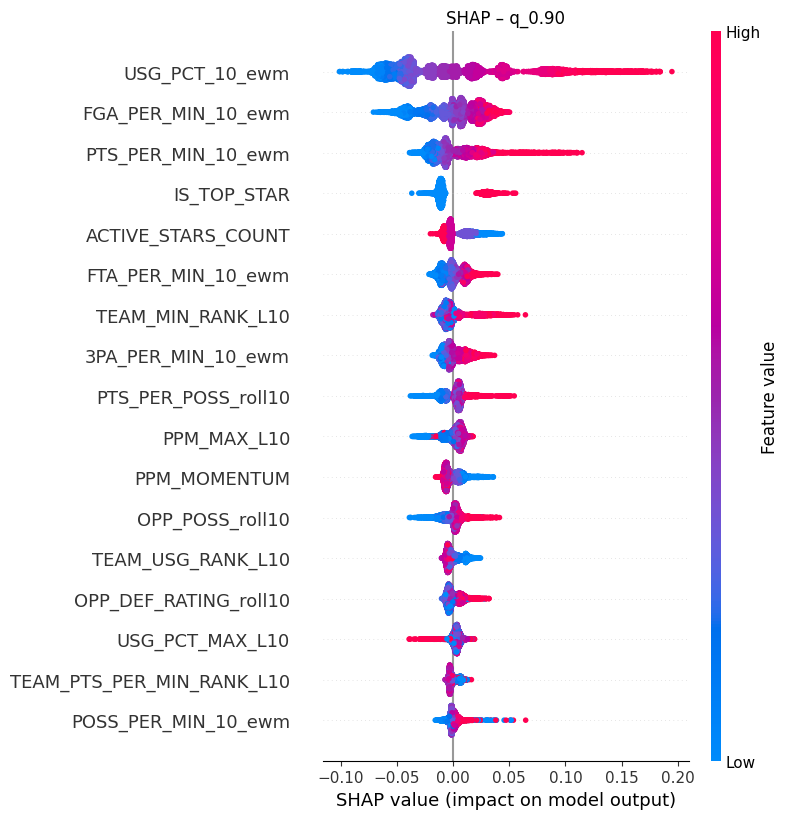

In [18]:
import shap

for q_key, model in quantile_models.items():
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_val_f)
    
    print(f"\n── {q_key} ──")
    shap.plots.beeswarm(shap_values, max_display=30, show=False)
    plt.title(f"SHAP – {q_key}")
    plt.tight_layout()
    plt.show()

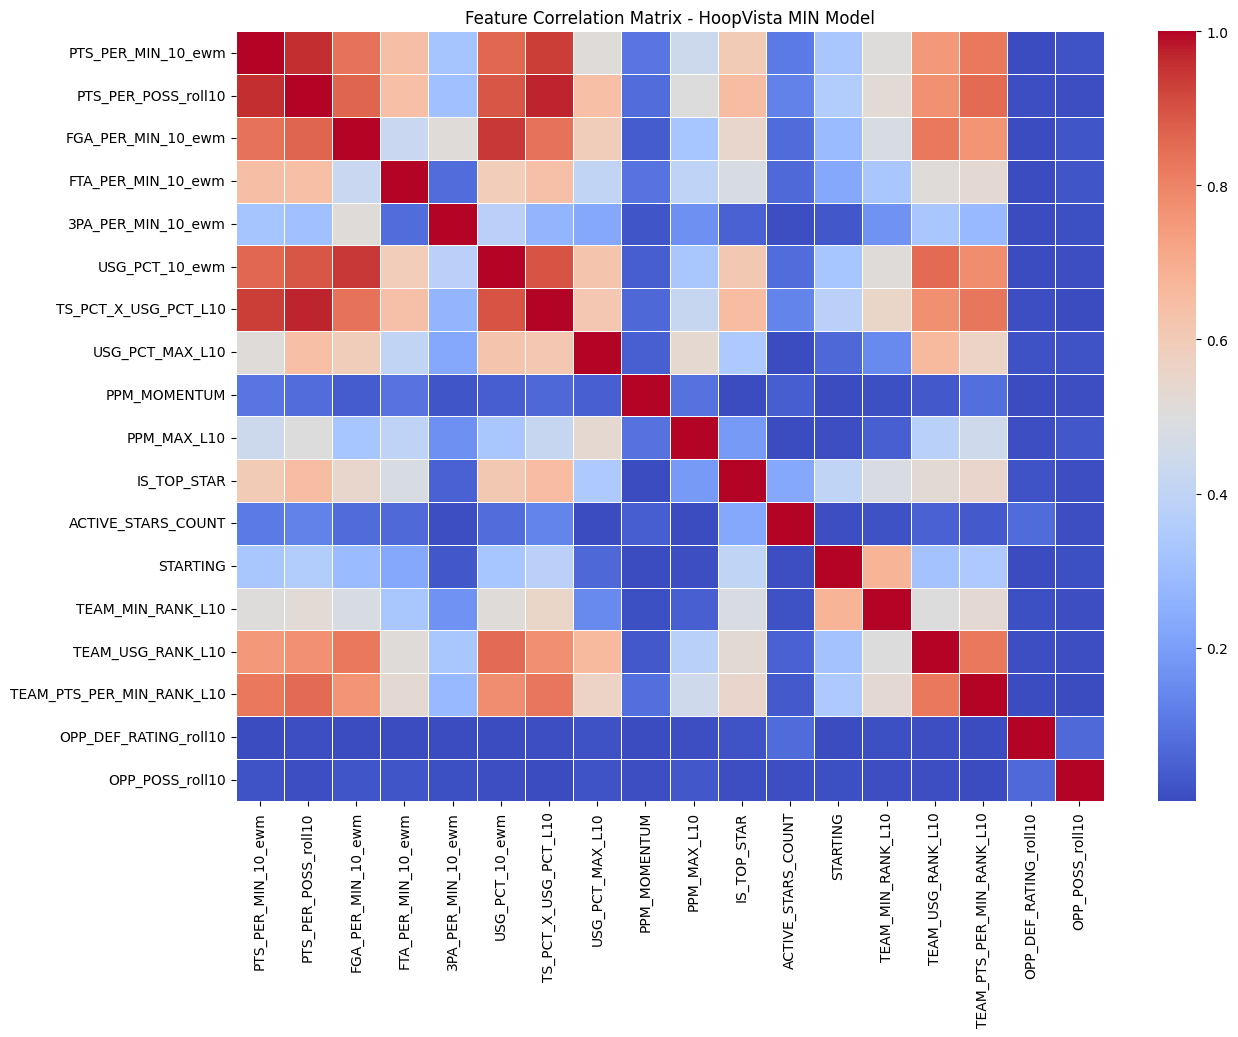

--- High Correlation Report (Threshold > 0.95) ---
TS_PCT_X_USG_PCT_L10 <-> PTS_PER_POSS_roll10: 0.9719
PTS_PER_POSS_roll10 <-> PTS_PER_MIN_10_ewm: 0.9587


['PTS_PER_POSS_roll10', 'TS_PCT_X_USG_PCT_L10']

In [85]:
import seaborn as sns

def analyze_correlations(df, features, threshold=0.95):
    """
    Analyzes feature correlations to identify redundancy in the MIN model.
    """
    # Calculate correlation matrix
    corr_matrix = df[features].corr().abs()
    
    # Create a mask for the upper triangle
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Identify features with correlation above threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # Plotting the Heatmap
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title(f'Feature Correlation Matrix - HoopVista MIN Model')
    plt.show()
    
    # Detailed report of high correlations
    print(f"--- High Correlation Report (Threshold > {threshold}) ---")
    high_corr_pairs = []
    for col in upper.columns:
        connected = upper.index[upper[col] > threshold].tolist()
        for c in connected:
            high_corr_pairs.append((col, c, upper.loc[c, col]))
            
    if not high_corr_pairs:
        print("No features exceed the correlation threshold.")
    else:
        for f1, f2, val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
            print(f"{f1} <-> {f2}: {val:.4f}")
            
    return to_drop

# Usage with your specific list
correlated_features = analyze_correlations(df, PPM_FEATURES)
correlated_features

In [86]:
import joblib
from pathlib import Path


bundle = {
    "quantile_models": quantile_models,
    "feature_names": PPM_FEATURES,  # or list(X_train_min.columns)
    "scaler": scaler
}
joblib.dump(bundle, "src/models/saved_models/ppm_quantile_xgb.joblib")

['src/models/saved_models/ppm_quantile_xgb.joblib']

## PPM MODEL + MIN MODEL Analysis

In [4]:
# date = pd.Timestamp.now().normalize()  # midnight today, local tz
# current_date = date.strftime("%Y-%m-%d")

# # target_date = pd.Timestamp("2026-03-26")
# # hist = df[df["GAME_DATE"] < target_date].copy()

# lines_dfs = pd.read_csv('data/raw/player_lines/NBA_DFS_20260403_163051.csv')
# lines_us = pd.read_csv('data/raw/player_lines/NBA_US_20260403_163203.csv')
# lines_dfs = lines_dfs[(lines_dfs['BOOKMAKER'] == 'Underdog') & (lines_dfs['CATEGORY'] == 'player_points')]
# names = lines_dfs['NAME'].unique()
# names

today = datetime.today().strftime('%Y%m%d')  
current_date = datetime.now().strftime('%Y-%m-%d')
target_date = pd.Timestamp("2026-04-11")
hist = df[df["GAME_DATE"] < target_date].copy()

lines_dfs = pd.read_csv('data/raw/player_lines/NBA_DFS_20260411_140648.csv')
lines_dfs = lines_dfs[(lines_dfs['BOOKMAKER'] == 'Underdog') & (lines_dfs['CATEGORY'] == 'player_points')]
names = lines_dfs['NAME'].unique()
names

array(['Bam Adebayo', 'Tyler Herro', 'Jaime Jaquez Jr', 'Davion Mitchell',
       "Kel'el Ware", 'Kawhi Leonard', 'Darius Garland',
       'Bennedict Mathurin', 'Scoot Henderson', 'Jrue Holiday',
       'Deni Avdija', 'Donovan Clingan', 'Toumani Camara',
       'Maxime Raynaud', 'Daeqwon Plowden', 'Devin Carter'], dtype=object)

In [10]:
records = []

for name in names:
    try:
        if name in nameDict:
            name = nameDict[name]

        min_feats = min_pipeline(df, name, current_date)
        if min_feats is None:
            raise ValueError("min_pipeline returned None (need >= 10 games)")

        ppm_feats = ppm_pipeline(df, name, current_date)
        # ppm_pipeline returns a list aligned with PPM_FEATURES / training columns

        min_arr = np.asarray(min_feats, dtype=float).reshape(1, -1)
        ppm_arr = np.asarray(ppm_feats, dtype=float).reshape(1, -1)

        m10 = float(min_quantile_models["q_0.10"].predict(min_arr)[0])
        m50 = float(min_quantile_models["q_0.50"].predict(min_arr)[0])
        m90 = float(min_quantile_models["q_0.90"].predict(min_arr)[0])

        p10 = float(ppm_quantile_models["q_0.10"].predict(ppm_arr)[0])
        p50 = float(ppm_quantile_models["q_0.50"].predict(ppm_arr)[0])
        p90 = float(ppm_quantile_models["q_0.90"].predict(ppm_arr)[0])

        # implied PTS = minutes × PTS per minute (same quantile index on both sides)
        pts10 = m10 * p10
        pts50 = m50 * p50
        pts90 = m90 * p90

        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": m10,
            "PRED_MIN_Q50": m50,
            "PRED_MIN_Q90": m90,
            "PRED_PPM_Q10": p10,
            "PRED_PPM_Q50": p50,
            "PRED_PPM_Q90": p90,
            "PRED_PTS_Q10": pts10,
            "PRED_PTS_Q50": pts50,
            "PRED_PTS_Q90": pts90,
            "PRED_PTS_RANGE_10_90": pts90 - pts10,
        })

    except Exception as e:
        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": np.nan,
            "PRED_MIN_Q50": np.nan,
            "PRED_MIN_Q90": np.nan,
            "PRED_PPM_Q10": np.nan,
            "PRED_PPM_Q50": np.nan,
            "PRED_PPM_Q90": np.nan,
            "PRED_PTS_Q10": np.nan,
            "PRED_PTS_Q50": np.nan,
            "PRED_PTS_Q90": np.nan,
            "PRED_PTS_RANGE_10_90": np.nan,
        })
        print(f"[SKIP] {name}: {e}")

preds_df = pd.DataFrame(records)
preds_df.head()

,PLAYER_NAME,PRED_MIN_Q10,PRED_MIN_Q50,PRED_MIN_Q90,PRED_PPM_Q10,PRED_PPM_Q50,PRED_PPM_Q90,PRED_PTS_Q10,PRED_PTS_Q50,PRED_PTS_Q90,PRED_PTS_RANGE_10_90
0,Bam Adebayo,7.266884,33.650997,44.387238,0.322626,0.586112,1.035865,2.344489,19.723256,45.979205,43.634716
1,Tyler Herro,11.670135,33.478523,44.817150,0.323220,0.583013,1.067012,3.772024,19.518426,47.820424,44.048400
2,Jaime Jaquez Jr.,14.258892,35.336914,43.086315,0.187986,0.521840,1.004989,2.680470,18.440214,43.301279,40.620809
3,Davion Mitchell,14.405640,33.244370,44.759659,0.154667,0.358826,0.800202,2.228082,11.928931,35.816769,33.588687
4,Kel'el Ware,15.144941,33.324505,40.978050,0.108241,0.427532,0.914231,1.639307,14.247293,37.463394,35.824087
